<a href="https://colab.research.google.com/github/sonurjs/student_marks_prediction/blob/main/student_marks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Marks Prediction**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Loading** **Dataset**

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/dataset/StudentPerformance.csv'
df = pd.read_csv(path)

df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


**Data** **Cleaning**

In [ ]:
df.isnull().sum()          # check missing values




,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.dropna()     # remove rows

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
df.duplicated().sum()



np.int64(127)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df.shape

(10000, 6)

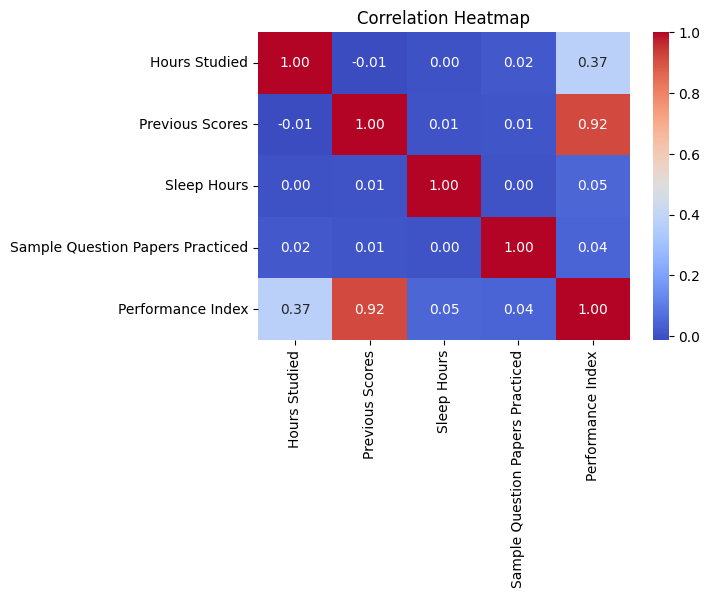

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# heat map
plt.figure(figsize=(6,4))
corr = df.drop(columns=['Extracurricular Activities']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


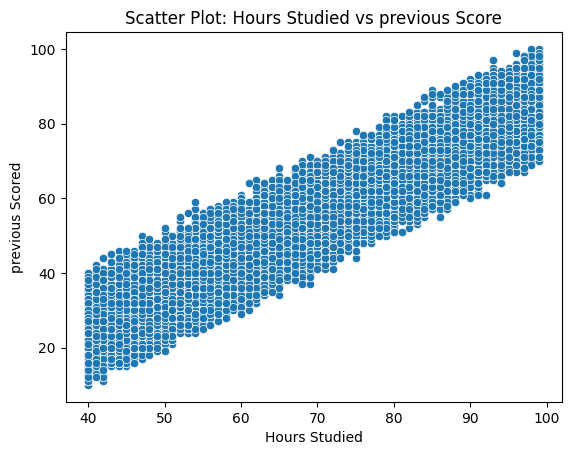

In [ ]:
sns.scatterplot(x='Previous Scores', y='Performance Index', data=df)
plt.title("Scatter Plot: Hours Studied vs previous Score")
plt.xlabel("Hours Studied")
plt.ylabel("previous Scored")
plt.show()


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Previous Scores', 'Hours Studied']]
y= df['Performance Index']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



In [29]:
y_pred = model.predict([[99,7]])
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([91.05660538])